# K-Means Clustering for Security Analytics

**Goal:** understand how K-means assigns observations to clusters, updates centroids, and decides when to stop. We will implement it with NumPy, then compare it with scikit-learn.

> The data and groups are synthetic. A cluster describes similarity, not malicious intent.

## 1. Objective and algorithm

K-means chooses $k$ centroids and minimizes within-cluster squared distance:

$$J = \sum_{i=1}^{n} \lVert x_i - \mu_{c_i} \rVert_2^2.$$

It repeats two steps: (1) assign each point to its nearest centroid and (2) replace each centroid with the mean of its assigned points. The algorithm stops when assignments or centroids stop changing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 207
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Create synthetic network sessions

We create three traffic patterns using connection duration and bytes transferred. The hidden scenario is retained only to evaluate the demonstration; K-means never receives it.

,duration_seconds,kilobytes_transferred
count,340.00,340.00
mean,7.74,403.87
std,6.95,318.07
min,0.19,34.62
25%,1.73,128.01
50%,6.12,294.31
75%,14.62,765.51
max,23.18,1185.65


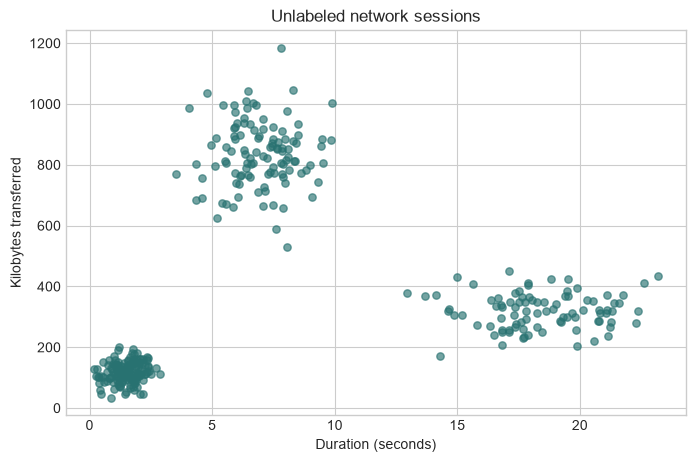

In [2]:
centers = np.array([[1.5, 120], [7.0, 850], [18.0, 320]])
scales = np.array([[0.55, 32], [1.35, 115], [2.4, 58]])
group_sizes = [140, 110, 90]
parts = [rng.normal(center, scale, size=(size, 2))
         for center, scale, size in zip(centers, scales, group_sizes)]
X = np.vstack(parts)
hidden_scenario = np.repeat(['short-low', 'bulk-transfer', 'long-medium'], group_sizes)
sessions = pd.DataFrame(X, columns=['duration_seconds', 'kilobytes_transferred'])
display(sessions.describe().round(2))

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=28, alpha=0.65, color='#287271')
plt.xlabel('Duration (seconds)')
plt.ylabel('Kilobytes transferred')
plt.title('Unlabeled network sessions')
plt.show()

## 3. Scale before measuring distance

Bytes have a much larger numeric range than seconds. Standardization prevents that unit from dominating Euclidean distance.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=sessions.columns).agg(['mean', 'std']).round(3)

,duration_seconds,kilobytes_transferred
mean,-0.000,0.000
std,1.001,1.001


## 4. Implement K-means from scratch

The distance array has shape `(number of observations, k)`. `argmin` assigns each row to its nearest centroid. Empty clusters are reinitialized to an observed point so the implementation remains usable.

In [5]:
def initialize_centroids(X, k, rng):
    """Choose a random first centroid, then repeatedly choose the farthest point."""
    centroids = [X[rng.integers(len(X))]]
    while len(centroids) < k:
        chosen = np.array(centroids)
        squared_distances = ((X[:, None, :] - chosen[None, :, :]) ** 2).sum(axis=2)
        distance_to_nearest = squared_distances.min(axis=1)
        centroids.append(X[distance_to_nearest.argmax()])
    return np.array(centroids)


def kmeans_from_scratch(X, k, max_iterations=100, tolerance=1e-4, random_state=207):
    local_rng = np.random.default_rng(random_state)
    centroids = initialize_centroids(X, k, local_rng)
    inertia_history = []

    for iteration in range(max_iterations):
        squared_distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        labels = squared_distances.argmin(axis=1)
        inertia_history.append(squared_distances[np.arange(len(X)), labels].sum())

        new_centroids = np.empty_like(centroids)
        for cluster_id in range(k):
            members = X[labels == cluster_id]
            new_centroids[cluster_id] = (members.mean(axis=0) if len(members)
                                         else X[local_rng.integers(len(X))])

        centroid_shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if centroid_shift < tolerance:
            break

    squared_distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    labels = squared_distances.argmin(axis=1)
    inertia = squared_distances[np.arange(len(X)), labels].sum()
    return labels, centroids, inertia, np.array(inertia_history), iteration + 1


manual_labels, manual_centroids, manual_inertia, history, iterations = kmeans_from_scratch(
    X_scaled, k=3, random_state=RANDOM_STATE
)
print(f'Converged in {iterations} iterations')
print(f'Final inertia: {manual_inertia:.2f}')
print('Centroids in original units:')
display(pd.DataFrame(scaler.inverse_transform(manual_centroids), columns=sessions.columns).round(2))

Converged in 3 iterations
Final inertia: 30.84
Centroids in original units:


,duration_seconds,kilobytes_transferred
0,1.50,118.41
1,6.96,835.86
2,18.39,319.91


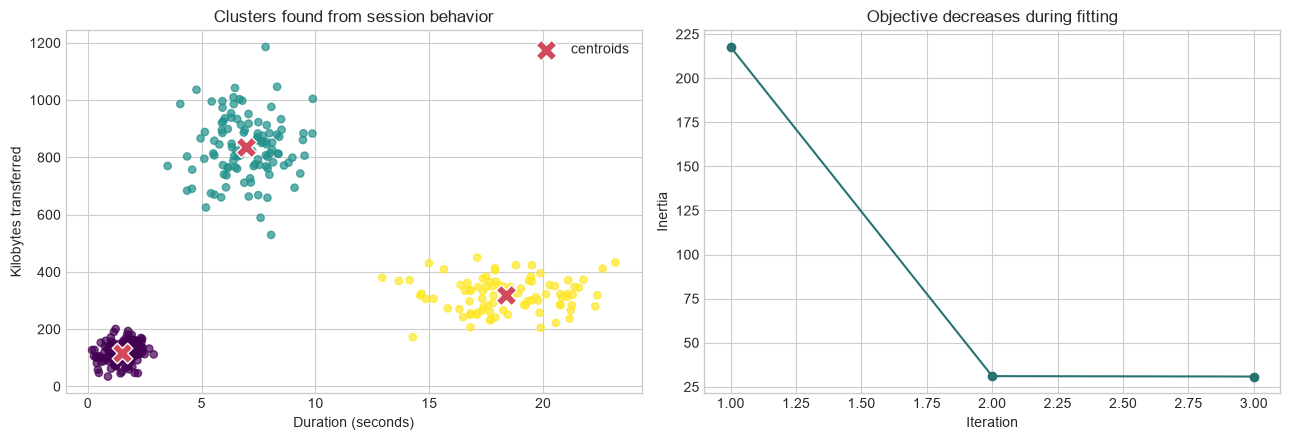

In [6]:
centroids_original = scaler.inverse_transform(manual_centroids)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(X[:, 0], X[:, 1], c=manual_labels, cmap='viridis', s=28, alpha=0.7)
axes[0].scatter(centroids_original[:, 0], centroids_original[:, 1],
                marker='X', s=220, c='#d1495b', edgecolor='white', label='centroids')
axes[0].set(xlabel='Duration (seconds)', ylabel='Kilobytes transferred',
            title='Clusters found from session behavior')
axes[0].legend()
axes[1].plot(np.arange(1, len(history) + 1), history, marker='o', color='#287271')
axes[1].set(xlabel='Iteration', ylabel='Inertia', title='Objective decreases during fitting')
plt.tight_layout()
plt.show()

## 5. Compare with scikit-learn

Production code should usually use the tested library implementation. Cluster IDs are arbitrary, so adjusted Rand index compares partitions without requiring matching ID numbers.

In [7]:
model = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
sklearn_labels = model.fit_predict(X_scaled)
print(f'scikit-learn inertia: {model.inertia_:.2f}')
print(f'manual vs sklearn adjusted Rand index: {adjusted_rand_score(manual_labels, sklearn_labels):.3f}')
print(f'silhouette score: {silhouette_score(X_scaled, sklearn_labels):.3f}')

scikit-learn inertia: 30.84
manual vs sklearn adjusted Rand index: 1.000
silhouette score: 0.850


## 6. Choose $k$: elbow and silhouette

Inertia always decreases as $k$ grows. Look for an elbow where improvement slows, and use silhouette score as a second view of cohesion and separation. Domain usefulness still matters more than either curve alone.

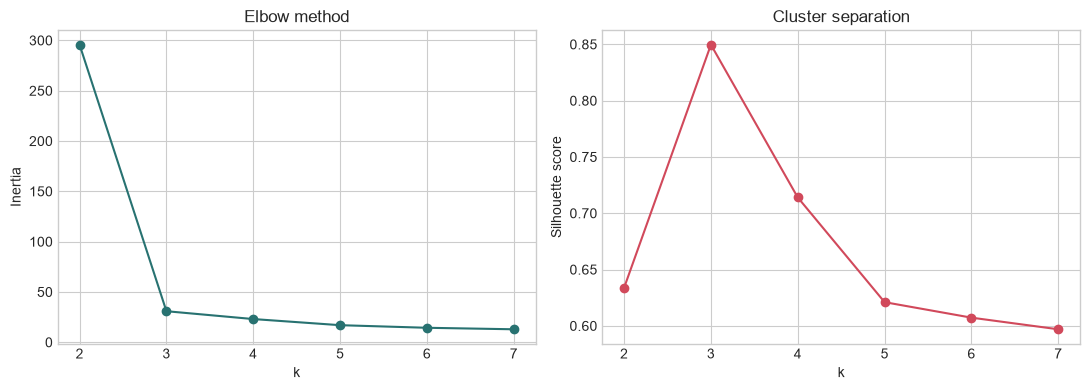

In [8]:
candidate_k = range(2, 8)
inertias, silhouettes = [], []
for k in candidate_k:
    candidate = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    candidate_labels = candidate.fit_predict(X_scaled)
    inertias.append(candidate.inertia_)
    silhouettes.append(silhouette_score(X_scaled, candidate_labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(candidate_k), inertias, marker='o', color='#287271')
axes[0].set(xlabel='k', ylabel='Inertia', title='Elbow method')
axes[1].plot(list(candidate_k), silhouettes, marker='o', color='#d1495b')
axes[1].set(xlabel='k', ylabel='Silhouette score', title='Cluster separation')
plt.tight_layout()
plt.show()

## 7. Interpretation and limitations

- K-means is useful for exploration, behavioral segmentation, and creating candidate features.
- Scale features before fitting when their units differ.
- Results depend on initialization; use multiple starts (`n_init`).
- K-means favors compact, roughly spherical groups and can be distorted by outliers.
- Cluster IDs have no inherent meaning. Analysts must inspect centroids and examples before attaching operational labels.